# Pelosi Alpha Capital

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
# seed=42

The daatset has 102,198 lines and8 columns.  Each line represents a different trade.  There are 100 days of data, and roughly 1,000 trades per day. The columns contain information about the following variables:  
- (1) Day $d$ of the trade; 
- (2) Time $t$ of the trade, in seconds after midnight; 
- (3) Fundamental value $v_d$,tof the stock immediately after the trade; 
- (4) Ask price $A_{d,t}$; 
- (5) Bidprice $B_{d,t}$; 
- (6) Number of buy orders $Buys_{d,t}$; 
- (7) Number of sell orders $Sells_{d,t}$; 
- (8) Signal given by the data provider $s_{d,t}$.

In [3]:
path=r"data.csv" 
data=pd.read_csv(path)
new = 'day sec_post_midnight fund_post_trade ask bid n_buy_orders n_sell_orders signal'.split(' ')
old = list(data.columns)
data=data.rename({old[i]:col for i, col in enumerate(new)}, axis=1)

In [4]:
data['delta_fund_post_trade'] = data['fund_post_trade'] - data['fund_post_trade'].shift(1)
data['fund_post_trade_prev']=data['fund_post_trade'].shift(1)
data=data.dropna()
data.head(5)

,day,sec_post_midnight,fund_post_trade,ask,bid,n_buy_orders,n_sell_orders,signal,delta_fund_post_trade,fund_post_trade_prev
1,1,32406.147188,100.00,99.980000,99.980000,7,3,0,0.02,99.98
2,1,32409.115557,100.02,100.004000,99.996000,4,6,1,0.02,100.00
3,1,32471.025717,100.04,100.021333,100.018667,6,4,1,0.02,100.02
4,1,32473.743952,100.02,100.042000,100.038000,8,2,1,-0.02,100.04
5,1,32487.492880,100.04,100.020000,100.020000,5,5,0,0.02,100.02


In [5]:
def accuracy_indicator(row):
    if row['delta_fund_post_trade']>0 and row['signal']==1:
        return 1
    elif row['delta_fund_post_trade']<0 and row['signal']==0:
        return 1
    else:
        return 0

In [6]:
data['signal_accurate']=data.apply(lambda row: accuracy_indicator(row), axis=1)
tau = data['signal_accurate'].sum()/len(data)
step_size = np.abs(data['delta_fund_post_trade']).mean()

In [11]:
def exepcted_profit(N_informed, 
                    tau,
                    size, 
                    # seed,
                    step_size,
                    D=100, 
                    T=1_000, 
                    total_traders=10, 
                    v_0=100, 
                    S_0=0
                    ):
    

    """
    NECESSARY INPUT:
    N_informed          : Traders WITH access to signal 
    tau                 : Signal accuracy     
    size                : Set trade size to minimum order size
    seed                : Random seed for reproducibility

    OPTIONAL INPUT:
    D=100               : Trading days
    T=1_000             : Trades per day
    step_size=0.02      : Magnitude of price move per period
    total_traders = 10  : Total traders 
    min_order = 10_000  : Minimum order size
    v_0 = 100           : Initial stock price
    S_0 = 0             : Initial half-spread

    OUTPUT:
    pd.DataFrame({'Signal Accuracy': "{0:0.4f}".format(tau), 
                'Informed Traders': N_informed,
                'Uninformed Traders':N_uninformed,
                'Expected Profit (USD)':"{0:0.0f}".format(profit)}, 
                index=['']
              ).T
    """

    if N_informed<1:
        print('There must be at least 1 informed trader')
        return

    # random.seed(seed)
    # np.random.seed(seed)

    # To ensure total traders constraint is respected
    N_uninformed=total_traders-N_informed

    profit = 0          # Initialise profit
    v_prev = v_0        # Initialise price

    for d in range(D):

        # Half-spread and adverse cumulative selection are reset daily
        S_prev=S_0
        cum_adverse_selection = 0

        for t in range(T):

            # Market maker uses pre-trade half-spread for quotes
            ask = v_prev + S_prev
            bid = v_prev - S_prev

            # For each period there's - stock price step of fixed magnitude
            step = random.choice([-1,1])*step_size
            v_t = v_prev + step

            # Conditional on price step, signal is selected with probability tau
            if step>0:
                s = random.choices([1,0], weights = [tau, 1-tau])[0]
            if step<0:
                s = random.choices([0,1], weights = [tau, 1-tau])[0]
            
            # Uninformed sells and buys are randomly selected
            sells = np.random.binomial(N_uninformed,0.5)
            buys=N_uninformed-sells


            # If expectation of fundamental falls outside of bid-ask
            if S_prev<(2*tau-1)*step_size:
                if s==1:
                    profit += (v_t - ask)*size
                    buys += N_informed
                elif s==0:
                    profit += (bid - v_t)*size
                    sells += N_informed


            # Post-trade updates 
            v_prev = v_t
            cum_adverse_selection += step * (sells - buys)
            S_prev = max(0, -0.1 * cum_adverse_selection / (t + 1))


    results = pd.DataFrame({'Signal Accuracy': "{0:0.4f}".format(tau), 
                'Informed Traders': N_informed,
                'Uninformed Traders':N_uninformed,
                'Expected Profit (USD)':"{0:0.0f}".format(profit)}, 
                index=['']
              ).T
    
    return results 

### Single Informed Trader (10 in Total)

In [12]:
min_order = 10_000  # Minimum order size
results1 = exepcted_profit(N_informed=1, 
                           tau=tau, 
                           size=min_order, 
                        #    seed=seed, 
                           step_size=step_size)
print(results1)

                              
Signal Accuracy         0.5967
Informed Traders             1
Uninformed Traders           9
Expected Profit (USD)  3451902


Since we have information on neither the risk aversion nor the capitalisaiton of the fund, the expected profit is a reasonable price quote.

### Two Informed Traders (10 in Total)

In [13]:
min_order = 10_000  # Minimum order size
results2 = exepcted_profit(N_informed=2, 
                           tau=tau, 
                           size=min_order, 
                        #    seed=seed, 
                           step_size=step_size)
print(results2)

                              
Signal Accuracy         0.5967
Informed Traders             2
Uninformed Traders           8
Expected Profit (USD)  3091172


### Expected Profit vs Informed Traders

In [19]:
exepcted_profit(N_informed=N+1, 
                           tau=tau, 
                           size=min_order, 
                        #    seed=seed, 
                           step_size=step_size).T['Expected Profit (USD)']

    641024
Name: Expected Profit (USD), dtype: object

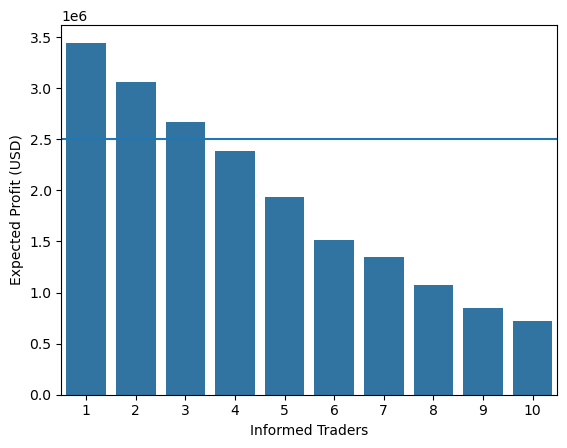

In [15]:
results3={}
for N in range(10):

    results3[N+1]=exepcted_profit(N_informed=N+1, 
                           tau=tau, 
                           size=min_order, 
                        #    seed=seed, 
                           step_size=step_size).T['Expected Profit (USD)']

df=pd.DataFrame(results3).T.reset_index()
df=df.rename({'index':'Informed Traders', '':'Expected Profit (USD)'}, axis=1)
df['Expected Profit (USD)']=pd.to_numeric(df['Expected Profit (USD)'])

data_price = 2_500_000

sns.barplot(x=df['Informed Traders'], y=df['Expected Profit (USD)'])
plt.axhline(data_price)

### Monte-Carlo

In [29]:
results_mc=[]
sims=
for _ in range(sims):

    results_mc.append(
        exepcted_profit(N_informed=1, 
                           tau=tau, 
                           size=min_order, 
                        #    seed=seed, 
                           step_size=step_size).T['Expected Profit (USD)']
                           )
results_mc = np.array(results_mc)
results_mc

SyntaxError: invalid syntax (2516545363.py, line 2)

[    686765
 Name: Expected Profit (USD), dtype: object,
     756971
 Name: Expected Profit (USD), dtype: object,
     741980
 Name: Expected Profit (USD), dtype: object,
     752391
 Name: Expected Profit (USD), dtype: object,
     663914
 Name: Expected Profit (USD), dtype: object,
     704689
 Name: Expected Profit (USD), dtype: object,
     695780
 Name: Expected Profit (USD), dtype: object,
     724543
 Name: Expected Profit (USD), dtype: object,
     705164
 Name: Expected Profit (USD), dtype: object,
     697649
 Name: Expected Profit (USD), dtype: object,
     686765
 Name: Expected Profit (USD), dtype: object,
     756971
 Name: Expected Profit (USD), dtype: object,
     741980
 Name: Expected Profit (USD), dtype: object,
     752391
 Name: Expected Profit (USD), dtype: object,
     663914
 Name: Expected Profit (USD), dtype: object,
     704689
 Name: Expected Profit (USD), dtype: object,
     695780
 Name: Expected Profit (USD), dtype: object,
     724543
 Name: Expected Pro

[                              
 Signal Accuracy         0.5967
 Informed Traders             2
 Uninformed Traders           8
 Expected Profit (USD)  3172233,
                               
 Signal Accuracy         0.5967
 Informed Traders             2
 Uninformed Traders           8
 Expected Profit (USD)  3172233,
                               
 Signal Accuracy         0.5967
 Informed Traders             2
 Uninformed Traders           8
 Expected Profit (USD)  3172233,
                               
 Signal Accuracy         0.5967
 Informed Traders             2
 Uninformed Traders           8
 Expected Profit (USD)  3172233,
                               
 Signal Accuracy         0.5967
 Informed Traders             2
 Uninformed Traders           8
 Expected Profit (USD)  3172233,
                               
 Signal Accuracy         0.5967
 Informed Traders             2
 Uninformed Traders           8
 Expected Profit (USD)  3172233,
                               
 S

In [ ]:
results3={}
for N in range(10):
v
    results3[N+1]=exepcted_profit(N_informed=N+1, 
                           tau=tau, 
                           size=min_order, 
                        #    seed=seed, 
                           step_size=step_size).T['Expected Profit (USD)']

df=pd.DataFrame(results3).T.reset_index()
df=df.rename({'index':'Informed Traders', '':'Expected Profit (USD)'}, axis=1)
df['Expected Profit (USD)']=pd.to_numeric(df['Expected Profit (USD)'])

data_price = 2_500_000

sns.barplot(x=df['Informed Traders'], y=df['Expected Profit (USD)'])
plt.axhline(data_price)

Given a total of 10 groups, only 3 groups will buy the data; The expected profit exceeds data price with just 3 informed players. The fourth group in line will decide against the purchase since that would constitute a guaranteed loss on expectation. Assuming our funds is first, second or third in line, only 2 other groups will pay for the data. 

#### Why didn't we iterate over 30-sec periods, with limit of 1,000 trades, instead iterating over 100 trades?
Delaying a profitable trade is sub-optimal, because the future signal yields the same expected economic benefit as the current.
